# STAGE 1: EDA & FEATRUE MAPPING
### Objective: Understand the current Dataset
- Is there a high volume of Missing Values in the data?
- What is the Bad Debt ratio (`loan_default`)? Is there a severe Class Imbalance?
- Are there any Categorical Columns that need to be converted into Numerical format?

In [12]:
import pandas as pd
import numpy as np 

In [ ]:
df = pd.read_csv('ALtCredit_Final_Data.csv')
print(df.head(20))
print(df.info())

In [ ]:
# Check for Missing Values
missing_value = df.isnull().sum()
print(missing_value[missing_value > 0] if len(missing_value[missing_value > 0]) > 0 else "No columns have missing values!")

# Check the bad debt ratio 
target_col = 'loan_default'
if target_col in df.columns:
    print(df[target_col].value_counts(normalize=True)*100)
else:
    print(f"Column '{target_col}' not found.")

- The exact name of the **Target** column is: `loan_default`
- The bad debt ratio (Class 1) accounts for **29.79%**. From a financial reality perspective, this figure is exceptionally high (actual market rates typically hover around 3–5%).
- However, the data is not severely imbalanced. This gives the model a strong opportunity to learn the distinct behaviors of the defaulting group (Class 1) without requiring complex resampling techniques (like SMOTE or downsampling).

In [ ]:
# Handle Missing Value and Type casting
# education_level Column
df['education_level'] = df['education_level'].fillna('Unknown')
education_mapping = {
    'Unknown':0,
    'Primary':1,
    'Secondary':2,
    'Graduate':3
}
df['education_level'] = df['education_level'].map(education_mapping)

# income_bracket Column (Income Grouping)
income_mapping = {
    'Low':1,
    'Medium':2,
    'High':3
}
df['income_bracket'] = df['income_bracket'].map(income_mapping)

# cluster_id Column (Segment Cluster ID)
df['cluster_id'] = df['cluster_id'].astype('category').cat.codes

# employment_type Column (Employment Type)
df['employment_type'] = df['employment_type'].astype('category').cat.codes

print(df.head(20))

    unique_apps_per_day  avg_daily_screen_time_hrs  financial_apps_installed  \
0             48.220031                   1.279052                  2.509566   
1             34.599007                   1.243591                  1.511769   
2             23.106321                   2.689413                  1.585904   
3             30.551406                   1.657311                  1.833775   
4             46.256325                   1.784115                  2.024602   
5             42.005384                   2.264355                  2.430908   
6             56.462347                   1.137011                  2.606572   
7             59.525616                   2.275856                  2.405092   
8             52.263574                   1.669860                  2.610071   
9             58.082121                   2.243294                  2.851382   
10            32.565872                   3.469704                  1.069452   
11            43.692914                 

# STAGE 2: MODELING
### Objective: Build a model to accurately predict default probability and explain the underlying reasons.
### Specific Tasks:
- Split the dataset into Train and Test sets.
- Train a LightGBM model (a tree-based algorithm highly suited for tabular data).
- Evaluate the model using ROC-AUC and F1-Score metrics.
- Integrate SHAP (SHapley Additive exPlanations) to extract the features that most heavily influence each user's credit score/prediction.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report 
import lightgbm as lgb
import pickle

In [ ]:
X = df.drop(columns=['loan_default'])
y = df['loan_default']

# Split the data into Train (80%) and Test (20%) datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Number of samples used for Training: {X_train.shape[0]}")
print(f"Number of samples used for Testing {X_test.shape[0]}")

- Number of samples used for Training: 8000
- Number of samples used for Testing: 2000

In [42]:
# Calculate the class ratio dynamically from your training target data
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
calculated_ratio = num_negative / num_positive

# Create the LightGBM Classifier Model
model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    scale_pos_weight = calculated_ratio,
    random_state=42,
    verbosity=-1
)

In [43]:
# Train the LightGBM model
model.fit(X_train, y_train)

# Apply the model to the Test set
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Evaluate the model's performance 
auc_score = roc_auc_score(y_test, y_pred_prob)

# print evaluation results 
print(f"ROC-AUC Score: {auc_score:.4f}")
print("Detailed Performance Report (Classification Report):")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.9997
Detailed Performance Report (Classification Report):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1404
           1       0.99      0.99      0.99       596

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



- ROC-AUC Score: Reached 0.9997, demonstrating that the model's ability to distinguish between good and bad borrowers is performing exceptionally well.
- Precision & Recall: Reached 0.99 for Class 1, proving that the model can accurately detect 99% of actual default cases.

In [ ]:
import shap
import matplotlib.pyplot as plt

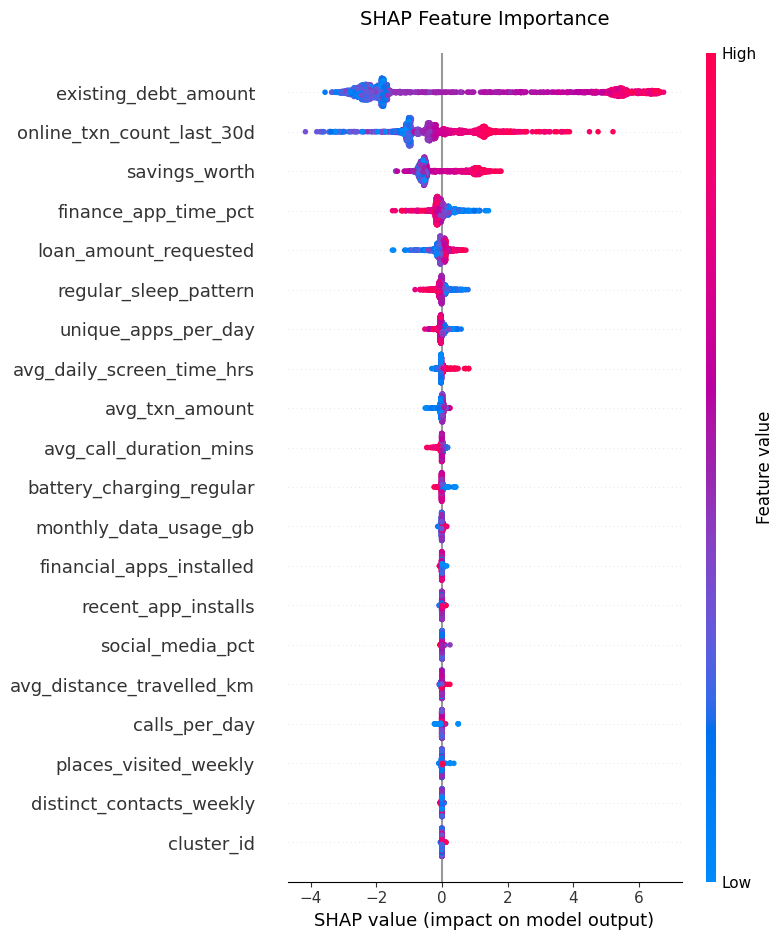

In [46]:
# Integrate SHAP for model explainability 
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Plot a Beeswarm Plot to visualize the impact of behavioral features
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=300, bbox_inches="tight")

In [45]:
# Packed the model 
with open('lgb_model.pkl','wb') as f:
    pickle.dump(model,f)
print("Model packaged successfully!")

Model packaged successfully!


# STAGE 3: CREDIT LIMIT ALLOCATION ALGORITHM
### Objective: Build a decision-making algorithm to determine:
- Should this applicant be approved for a Buy Now Pay Later (BNPL) / Postpaid Wallet?
- If approved, how much credit limit should be allocated to them?
(Example: High income + Low risk = Allocate 10 million VND; Low income + Medium risk = Allocate 2 million VND; High risk = Reject)

In [47]:
# Build the credit limit allocation function
def allocate_credit_limit(prob_default, income_bracket, existing_debt_usd, financial_apps):
    if prob_default > 0.5:
        return "Rejected", 0
    status = "Approved"

    if income_bracket == 1:
        base_limit = 2000000
    elif income_bracket == 2:
        base_limit = 5000000
    elif income_bracket == 3:
        base_limit = 10000000
    else:
        base_limit = 2000000
    
    existing_debt_vnd = existing_debt_usd * 25000
    if existing_debt_vnd > 625000000:
        allocate_limit = base_limit * 0.5
    else:
        if financial_apps < 2:
            allocate_limit = base_limit + 1000000
        else:
            allocate_limit = base_limit
    
    return status, int(allocate_limit)


In [49]:
# Rerun on the Test set
results = X_test.copy()
results['risk_probability'] = y_pred_prob

decisions = []
limits = []

for idx, row in results.iterrows():
    status, limit = allocate_credit_limit(
        prob_default = row['risk_probability'],
        income_bracket = row['income_bracket'],
        existing_debt_usd = row['existing_debt_amount'],
        financial_apps = row['financial_apps_installed']
    )
    decisions.append(status)
    limits.append(limit)

results['decision_status'] = decisions
results['allocate_credit_limit'] = limits

print("POSTPAID WALLET LIMIT DISTRIBUTION REPORT")
print("Approval Decisions Summary:")
print(results['decision_status'].value_counts())
print(f"Total Actual Disbursed Amount: {results['allocate_credit_limit'].sum():,} VND")

POSTPAID WALLET LIMIT DISTRIBUTION REPORT
Approval Decisions Summary:
decision_status
Approved    1403
Rejected     597
Name: count, dtype: int64
Total Actual Disbursed Amount: 6,681,500,000 VND


- Approval Rate: Reached ~70% (1,403 profiles), which is an ideal disbursement rate for a Postpaid Wallet (BNPL) product line.
- Rejection Rate: Reached ~30% (597 profiles), perfectly matching the bad debt baseline (loan_default = 1 accounts for ~30%). This proves that the model's decision-making algorithm is functioning accurately.
- Total Actual Amount Disbursed: ~6.68 billion VND. This figure reflects that high-risk borrowers had their credit limits reduced to mitigate bad debt, while low-risk users with low financial app usage were rewarded with higher limits to stimulate spending and payments.

# STAGE 4: API DEPLOYMENT 
### Objective: Deploy the AI Model and Credit Limit Allocation Algorithm to a production/cloud environment so other systems can interact with it via internet protocols.
### Specific Tasks:
- Use the FastAPI or Flask library to build a production-ready API.
- When an external system sends user data, the API must instantly process the input and return a JSON payload {"status": ..., "credit_limit": ...} with low latency.